# Γιάννης Φίλλης ΑΜ:5380, Κωνσταντίνος Ζώης ΑΜ:5226

## Ερώτημα 3

### Βήμα 1

In [29]:
import numpy as np
import pandas as pd

Το πρώτο που θα κάνουμε είναι να φορτώσουμε τα δεδομένα μας

In [30]:
train = pd.read_csv("data_train.csv")
test = pd.read_csv("data_test.csv")

In [31]:
train.describe()

,uid,mid,rating
count,90004.000000,90004.000000,90004.000000
mean,346.120217,1660.571230,3.542015
std,195.129819,1892.439785,1.058245
min,0.000000,0.000000,0.500000
25%,181.000000,327.000000,3.000000
50%,366.000000,873.500000,4.000000
75%,519.000000,2344.000000,4.000000
max,670.000000,9065.000000,5.000000


In [32]:
test.describe()

,uid,mid,rating
count,10000.000000,10000.00000,10000.000000
mean,345.031100,1662.64250,3.557950
std,195.476799,1907.64071,1.056375
min,0.000000,0.00000,0.500000
25%,176.000000,328.00000,3.000000
50%,362.000000,872.00000,4.000000
75%,518.000000,2357.50000,4.000000
max,670.000000,9060.00000,5.000000


Αρχικά, θα υπολογίσουμε την μέση βαθμολογία του κάθε χρήστη και την μέση βαθμολογία της κάθε ταινίας.  
Θα υπολογίσουμε και τον γενικό μέσο όρο για τις περιπτώσεις ταινιών οι οποίες είναι στο test set αλλά όχι στο training set

In [33]:
user_mean = train.groupby('uid')['rating'].mean()
movies_mean = train.groupby('mid')['rating'].mean()
general_avg = train.rating.mean()

Τώρα θα δημιουργήσουμε τις δύο συναρτήσεις μας, οι οποίες για κάθε ζευγάρι (u,m)  θα επιστρέφουν η μία το μέσο όρο της βαθμολογίας του χρήστη και η άλλη τον μέσο όρο της βαθμολογίας της ταινίας.

In [34]:
def user_average(u):
    return user_mean.get(u, general_avg)

def item_average(m):
    return movies_mean.get(m, general_avg)

In [35]:
user_avg = test.apply(lambda x: user_average(x['uid']),axis=1)

In [36]:
movies_avg = test.apply(lambda x: item_average(x['mid']),axis=1)

In [37]:
user_avg

,0
0,4.000000
1,3.776368
2,3.446809
3,3.525234
4,2.885604
...,...
9995,3.519403
9996,3.956522
9997,2.649199
9998,3.752660


In [38]:
movies_avg.info()

<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: None
Non-Null Count  Dtype  
--------------  -----  
10000 non-null  float64
dtypes: float64(1)
memory usage: 78.3 KB


Αφού λοιπόν έχουμε προβλέψει τις μέσες βαθμολογίες, αυτό που θα κάνουμε τώρα είναι να υπολογίσουμε το RMSE.  
Οπότε, θα χρησιμοποιήσουμε την έτοιμη συνάρτηση από την sklearn όπου θα έχουμε ως y_true αυτά που δίνονται στο test και ως y_pred αυτά που προβλέψαμε σε κάθε περίπτωση.

In [39]:
from sklearn.metrics import root_mean_squared_error
user_based = root_mean_squared_error(test.rating,user_avg)
item_based = root_mean_squared_error(test.rating, movies_avg)

In [40]:
print("User average RMSE: ",user_based)
print("Item average RMSE: ",item_based)


User average RMSE:  0.9612850028952498
Item average RMSE:  0.9860185686573368


Παρατηρώντας τις δύο τιμές του **RMSE** μπορούμε να δούμε πως αποδίδει λίγο καλύτερα η μέθοδος **User Average**.

### Βήμα 2

Το πρώτο πράγμα που θα κάνουμε είναι να ορίσουμε τον sparse πίνακα μας, χρησιμοποιώντας την συνάρτηση csr_matrix. Ως παράμετρους θα περάσουμε τα ratings ως τιμές, τα user ids στις γραμμές και τα movie ids ως στήλες. Όπως συζητήθηκε στο φροντιστήριο, υπάρχουν πολλές μορφές **sparse πινάκων**. Για λόγους βελτιστοποίησης χρόνου θα δημιουργήσουμε τον πίνακά μας ως **coo** και έπειτα θα τον μετατρέψουμε σε csr ώστε να μπορούμε να κάνουμε τις πράξεις μας.

In [41]:
from scipy.sparse import csr_matrix
from scipy.sparse import coo_matrix
row = train.uid
column = train.mid
data = train.rating

# a matrix R with R[trainset["uid"],trainset["mid"]] = trainset["rating"] will be created
R = coo_matrix((train['rating'], (train['uid'], train['mid']))).tocsr()

In [42]:
R.get_shape()

(671, 9066)

Το επόμενο βήμα είναι να δημιουργήοσυμε το Singular Value Decomposition του πίνακα.

In [43]:
import scipy.sparse.linalg as sp_linalg

U, s, V = sp_linalg.svds(R,k=20)

Παρακάτω θα χρησιμοποιήσουμε την argsort προκειμένου να πάρουμε τα σωστά indexes των πινάκων

In [44]:
idx = np.argsort(s)[::-1]
s = s[idx]
U = U[:, idx]
V = V[idx,:]


Αφού κάναμε όλα αυτά τώρα θα πάμε για κάθε k που ζητείται να υπολογίσουμε την τιμή Rk[u,m].

In [45]:
test_users = test.uid.values
test_movies = test.mid.values
test_ratings = test.rating.values

rmse_svd = []
for k in range(1,21):
    predictions_svd = np.zeros(len(test_users))
    for i in range (len(test_users)):
        u = test_users[i]
        m = test_movies[i]

        prod = (U[u, :k] @ np.diag(s[:k]))
        predictions_svd[i] = np.dot(prod, V[:k, m])
    predictions_svd = np.clip(predictions_svd,0, 5)
    rmse_value = root_mean_squared_error(test_ratings, predictions_svd)
    rmse_svd.append(rmse_value)

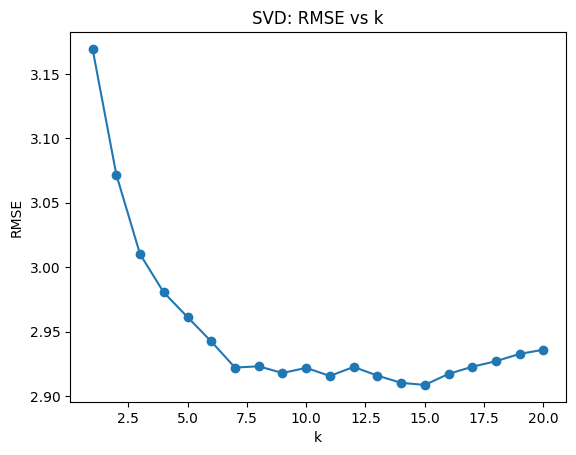

In [46]:
import matplotlib.pyplot as plt
k_range = [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20]
plt.plot(k_range, rmse_svd, marker='o')
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("SVD: RMSE vs k")
plt.show()

In [47]:
print("min value of rmse: ",rmse_svd[14])

min value of rmse:  2.90865182388992


Όπως μπορούμε να δούμε από το γράφημα, το rmse ξεκινάει από υψηλή τιμή και καθώς το k αυξάνεται, αυτό μειώνεται απότομα, μέχρι το k=7. Από εκεί και πέρα όσο αυξάνεται το k υπάρχει μια σχετική σταθεροποίηση του rmse ωστόσο βλέπουμε πως για **k = 15** επιτυγχάνεται η ελάχιστη τιμή του rmse, η οποία είναι **2.9** . Από εκεί μέχρι και το k=20 παρατηρείται μία ελαφριά αύξηση του rmse, το οποίο μπορεί να οφείλεται σε overfitting του αλγορίθμου.

In [48]:
counter = 0
for i in range(len(predictions_svd)):
    if(predictions_svd[i] <1):
        counter = counter+1
print("Number of predicted Ratings less than 1 :",counter)
print("Total predictions: ",len(predictions_svd))

Number of predicted Ratings less than 1 : 6582
Total predictions:  10000


Όπως μπορούμε να δούμε παραπάνω ένα πολύ μεγάλο πλήθος των ratings προβλέπει ότι είναι κάτω από 1.

### Βήμα 4

#### Βήμα 4.1

Σε αυτό το σημείο θα δημιουργήσουμε τις βοηθητικές συναρτήσεις τις οποίες θα χρειαστούμε παρακάτω.  

In [49]:
from sklearn.metrics.pairwise import cosine_similarity
def user_mean(R,u):
    row = R.getrow(u)
    return row.data.mean()

def item_users(R,m):
    col = R[:, m]
    rows, column = col.nonzero()
    return rows

def similar_users(R,u,m_users,k):
    #vector for specific user u
    u_vector = R[u,:]

    # vectors for specific m users
    m_vectors = R[m_users,:]

    similarities = cosine_similarity(u_vector, m_vectors).flatten()

    # k most similar
    idx_sorted = similarities.argsort()[::-1][:k]
    topk_users = m_users[idx_sorted]
    topk_similarities = similarities[idx_sorted]

    return topk_users, topk_similarities

def compute_score(k_ratings,k_similarities):
    denominator = np.sum(k_similarities)
    if denominator == 0:
        return 0.0
    return np.dot(k_similarities,k_ratings)/denominator





Εφόσον έχουμε υλοποιήσει τις βασικές συναρτήσεις που ζητούνται θα συνεχίσουμε με το να υλοποιήσουμε τον αλγόριθμο **UCF**.

#### Βήμα 4.2

Ο αλγόριθμος είναι απλός. Πρώτα παίρνουμε τους χρήστες που έκαναν rate την ταινία, μετά υπολογίζουμε την ομοιότητα και τους **top k**  όμοιους χρήστες, έπειτα παίρνει τα ratings αυτών και τέλος υπολογίζει το score που ζητείται.

In [50]:
def ucf(u,m,k):
    users_rated = item_users(R,m)
    if (len(users_rated) == 0):
        return user_mean(R,u)
    if len(users_rated)<k :
      topk_users, sims = similar_users(R,u,users_rated,len(users_rated))
    else:
      topk_users, sims = similar_users(R,u,users_rated,k)

    if sims.size == 0 or np.all(sims == 0):
      return 0.0

    ratings = R[topk_users,m].toarray().flatten()
    return compute_score(ratings, sims)

In [51]:
import time
k = [1,2,3,5,10,20,30,40,50,60,70,80,90,100]
rmse_ucf = []
t1 = time.time()
for value in k:
    predictions = []
    for uid, mid in zip(test.uid.values, test.mid.values):
        predictions.append(ucf(int(uid),int(mid),value))
    predictions = np.array(predictions)
    predictions = np.clip(predictions,0, 5)
    rmse_value = root_mean_squared_error(test.rating.values, predictions)
    rmse_ucf.append(rmse_value)
t = time.time() - t1
print("time:",t)
if(t >= 1000):
    print("Running time is over 1000 secs!")

time: 274.4691333770752


In [52]:
rmse_ucf

[1.2266901991872599,
 1.0820995164230311,
 1.0366195697406786,
 0.999909759063901,
 0.9770242959711843,
 0.971204611719259,
 0.9700415923855438,
 0.9706340777197818,
 0.9708238941686649,
 0.9711648299891441,
 0.9710769147259783,
 0.9712225038441031,
 0.9715167226645984,
 0.9717233161229]

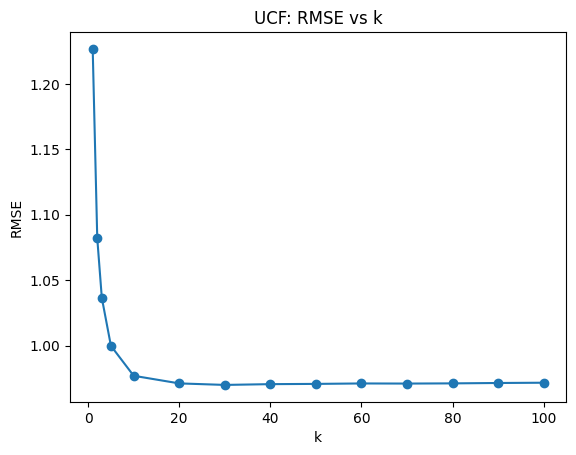

In [53]:
plt.plot(k, rmse_ucf, marker='o')
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("UCF: RMSE vs k")
plt.show()

In [54]:
print(rmse_ucf)

[1.2266901991872599, 1.0820995164230311, 1.0366195697406786, 0.999909759063901, 0.9770242959711843, 0.971204611719259, 0.9700415923855438, 0.9706340777197818, 0.9708238941686649, 0.9711648299891441, 0.9710769147259783, 0.9712225038441031, 0.9715167226645984, 0.9717233161229]


Μελετώντας την γραφική παράσταση, παρατηρούμε πως πάλι αρχίζει από πολύ υψηλή τιμή και καθώς αυξάνεται το k, αυτό μειώνεται πολύ απότομα. Από το k=10 και μετά φαίνεται σχεδόν να σταθεροποιείται. Φαίνεται πως η **ελάχιστη τιμή** του rmse είναι για **k = 30** και αν εκτυπώσουμε τον πίνακα rmse μπορούμε να επιβεβαιώσουμε πως η ελάχιστη τιμή είναι η έβδομη (που αντιστοιχεί στην έβδομη τιμή του πίνακα k που αντιστοιχεί στην τιμή 30).

#### Βήμα 4.3

Για να μπορέσουμε να βελτιώσουμε την ταχύτητα του αλγορίθμου θα εκμεταλευτούμε τις πράξεις που γίνονται στο κλάσμα που υπολογίζει την πρόβλεψη.  
Το σκεπτικό μας είναι ότι στον αριθμητή, ουσιαστικά σε κάθε loop για κάθε τιμή του k, έχουμε κάποιες κοινές τιμές, αφού καθώς αυξάνεται η τιμή του k στον αριθμητή θα έχουμε αυτές που είχαμε για την προηγούμενη τιμή του + επιπλέον τις καινούργιες που θα υπολογιστούν.  
Οπότε, αυτό που εν τέλει κάνουμε είναι να υπολογίζουμε εξαρχής αυτές τις τιμές και σε κάθε loop να παίρνουμε αυτό που χρειαζόμαστε.

In [55]:
def ucf_improved(u,m,k):
    users_rated = item_users(R,m)
    if (len(users_rated) == 0):
        return np.full(len(k), user_mean(R, u))

    #vector for specific user u
    u_vector = R[u,:]

    topk_users, sims = similar_users(R,u,users_rated,max(k))

    if sims.size == 0 or np.all(sims == 0):
      return np.full(len(k), 0.0)

    ratings = R[topk_users,m].toarray().flatten()

    cum_similarities = np.cumsum(sims)
    cum_similarities_ratings = np.cumsum(sims*ratings)

    predictions = []
    for value in k:
        value = min(value,len(topk_users)) #mporei na vrikame ligoterous apo k
        numerator = cum_similarities_ratings[value-1]
        denominator = cum_similarities[value-1]
        if denominator == 0:
            predictions.append(0.0)
        else:
            predictions.append(numerator/denominator)
    return np.array(predictions)


time: 19.60509204864502


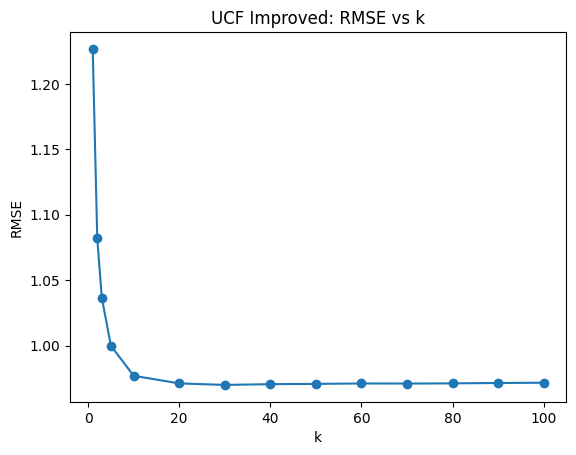

In [56]:
import time
k = [1,2,3,5,10,20,30,40,50,60,70,80,90,100]
rmse_ucf_improved = []
predictions = []
t1 = time.time()
for uid, mid in zip(test.uid.values, test.mid.values):
    predictions.append(ucf_improved(int(uid),int(mid),k))
t = time.time() - t1
print("time:",t)
if(t >= 100):
        print("Running time is over 100 secs!")
predictions = np.array(predictions)
for i, ki in enumerate(k):
    y_pred_k = predictions[:, i]
    rmse_value = root_mean_squared_error(test.rating.values, y_pred_k)
    rmse_ucf_improved.append(rmse_value)


plt.plot(k, rmse_ucf_improved, marker='o')
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("UCF Improved: RMSE vs k")
plt.show()

### Βήμα 5

Στο τελευταίο βήμα μας, αυτό που θα κάνουμε είναι να συγκεντρώσουμε τα αποτελέσματα και να τα συγκρίνουμε και να τα σχολιάσουμε.

In [57]:
results = { "algorithms": ["User Average", "Item Average","SVD","UCF","UCF-Improved"],
            "best_RMSE": [user_based, item_based, min(rmse_svd), min(rmse_ucf), min(rmse_ucf_improved)]}

df_results = pd.DataFrame(results)
df_results

,algorithms,best_RMSE
0,User Average,0.961285
1,Item Average,0.986019
2,SVD,2.908652
3,UCF,0.970042
4,UCF-Improved,0.970042


Στον παραπάνω πίνακα μπορούμε να δούμε τα καλύτερα(χαμηλότερα errors) από κάθε αλγόριθμο. Την καλύτερη επίδοση την έχει ο **User Average** με 0.96 και ακολουθούν οι **UCF** και **UCF-Improved** με 0.97. Οι δύο τελευταίοι φυσικά δεν έχουν διαφορά στο error αφού η ουσιαστική διαφορά τους είναι στον τρόπο που υλοποιήθηκαν με στόχο την βελτίωση του χρόνου και όχι του error. Έπειτα ακολουθεί ο **Item Average** με 0.98 error, οπότε βλέπουμε πως ο **User Average** αποδίδει αρκετά καλύτερα από τον **Item Average**.  
Στην τελευταία θέση φαίνεται να είναι ο **SVD** με error 2.9 . Αυτό το error είναι πολύ κακό, αλλά πιθανόν να οφείλεται στο ότι το μοντέλο μαθαίνει απευθείας πάνω στον αραιό πίνακα. Αυτός έχει στην συντριπτική πλειοψηφία του 0 στις γραμμές του, οπότε αναμένει οι περισσότερες βαθμολογίες να είναι 0.  
Άρα η σειρά είναι (από το χειρότερο προς το καλύτερο):  **SVD** < **Item Average** < **UCF** < **User Average**

### Bonus 1

Παρακάτω θα υλοποιήσουμε τον αλγόριθμο ucf όπου αφαιρούμε την μέση τιμή από τα ratings.  
Η λογική είναι παρόμοια με αυτή νωρίτερα, απλά τώρα λαμβάνουμε υπόψιν ότι θα πρέπει να αφαιρέσουμε και την μέση τιμή του rating και στο τέλος να προσθέσουμε την μέση τιμή των ratings του u. Υλοποιούμε την αργή εκδοχή του αλγορίθμου.

In [58]:
test_users = test.uid.values
test_movies = test.mid.values
test_ratings = test.rating.values

In [59]:
def ucf_mean(u,m,k):
    users_rated = item_users(R,m)
    if (len(users_rated) == 0):
        return user_mean(R,u)

    # taking user u
    u_vec = R[u,:]
    other_users_rated = R[users_rated,:]

    similarity = cosine_similarity(u_vec,other_users_rated).flatten()


    r_vi = R[users_rated, m].toarray().flatten()
    means_rv = np.array([user_mean(R,v) for v in users_rated])

    # (r_vi) - mean(rv)
    centered_ratings = r_vi - means_rv

    #sorting
    idx_sorted = similarity.argsort()[::-1]
    similarity_sorted = similarity[idx_sorted]
    centered_sorted = centered_ratings[idx_sorted]

    #choosing top k
    similarity_topk = similarity_sorted[:k]
    centered_topk = centered_sorted[:k]

    denominator = np.sum(np.abs(similarity_topk))

    if (denominator == 0 or np.isnan(denominator)):
        return user_mean(R,u)

    result = np.sum(similarity_topk*centered_topk)/denominator
    prediction = user_mean(R,u) + result

    if (np.isnan(prediction)):
        return user_mean(R,u)

    return prediction

In [60]:
import time
k = [1,2,3,5,10,20,30,40,50,60,70,80,90,100]
rmse_bonus1 = []

t1 = time.time()
for value in k:
    predictions = []
    for uid, mid in zip(test.uid.values, test.mid.values):
        predictions.append(ucf_mean(int(uid),int(mid),value))
    predictions = np.array(predictions)
    predictions = np.clip(predictions,0, 5)
    rmse_value = root_mean_squared_error(test.rating.values, predictions)
    rmse_bonus1.append(rmse_value)
t2 = time.time()
interval = t2-t1
print("time:",interval)
if(interval >= 1000):
    print("Running time is over 1000 secs!")

time: 677.7131516933441


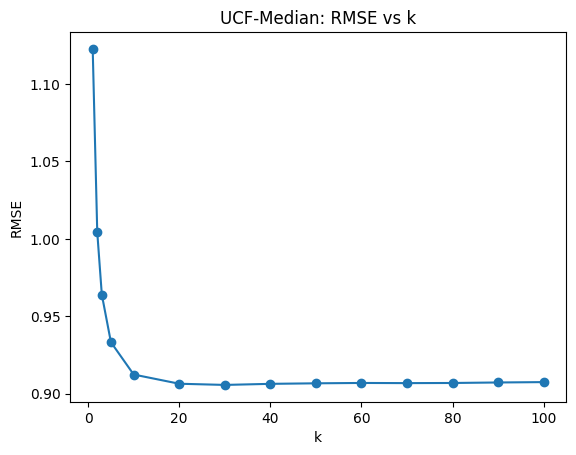

In [61]:
k = [1,2,3,5,10,20,30,40,50,60,70,80,90,100]
plt.plot(k, rmse_bonus1, marker='o')
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("UCF-Median: RMSE vs k")
plt.show()

In [62]:
print(rmse_bonus1)

[1.1226522347165402, 1.004322821835638, 0.9640515724976164, 0.9332830146855869, 0.9123990799041835, 0.9064573563807913, 0.9056918098234599, 0.9063882149511926, 0.9067299466494984, 0.9069609611388343, 0.9068553965954153, 0.9069448082801496, 0.9072715879982508, 0.9075074101079164]


Βλέπουμε πως η βελτιωμένη έκδοση με την αφαίρεση της μέσης τιμής αποδίδεις πολύ καλύτερα από όλες τις προηγούμενες μεθόδους, ίσως επειδή έτσι μειώνεται το bias των χρηστών που τείνουν να βαθμολογούν ψηλότερα ή χαμηλότερα. Πιο συγκεκριμένα, παίρνουμε το χαμηλότερο error για **k=30** όπου εκεί είναι **0.905**.

### Bonus 2

Παρακάτω θα υλοποιήσουμε το **Item Based Collaborative Filtering (ICF)**. Όπως λέει και η εκφώνηση, η λογική είναι ίδια με πριν απλά αντί για τις γραμμές που είχαμε πριν βάζουμε τις στήλες. Σύμφωνα με το documentation όμως, ένα πρόβλημα που δημιουργείται είναι ότι αφού ο R είναι csr, ο R.T θα είναι csc. Επειδή εμείς συνεχίζουμε να κάνουμε πράξεις και slicing στις γραμμές, κάτι τέτοιο θα είναι πολύ αργό. Οπότε, αυτό που κάνουμε είναι ότι βάζουμε ως csr τον R.T. Υλοποιούμε την αργή εκδοχή του αλγορίθμου.

In [63]:
print("type of R: ",type(R))
print("type of R.T: ",type(R.T))

type of R:  <class 'scipy.sparse._csr.csr_matrix'>
type of R.T:  <class 'scipy.sparse._csc.csc_matrix'>


In [64]:
def icf(u,m,k):
    users_rated = item_users(R_t,u)
    if (len(users_rated) == 0):
        return user_mean(R_t,m)
    if len(users_rated)<k :
      topk_users, sims = similar_users(R_t,m,users_rated,len(users_rated))
    else:
      topk_users, sims = similar_users(R_t,m,users_rated,k)

    if sims.size == 0 or np.all(sims == 0):
      return 0.0

    ratings = R_t[topk_users,u].toarray().flatten()
    return compute_score(ratings, sims)

In [65]:
import time
k = [1,2,3,5,10,20,30,40,50,60,70,80,90,100]
rmse_icf = []

R_t = R.T.tocsr()

t1 = time.time()
for value in k:
    predictions = []
    for uid, mid in zip(test.uid.values, test.mid.values):
        predictions.append(icf(int(uid),int(mid),value))
    predictions = np.array(predictions)
    predictions = np.clip(predictions,0, 5)
    rmse_value = root_mean_squared_error(test.rating.values, predictions)
    rmse_icf.append(rmse_value)
t = time.time() - t1
print("time:",t)
if(t >= 1000):
    print("Running time is over 1000 secs!")

time: 333.493736743927


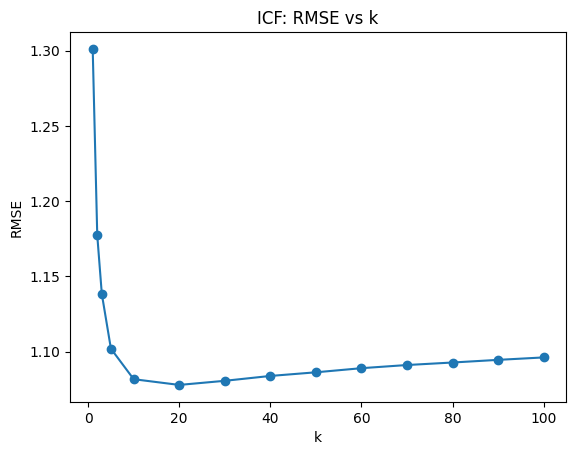

In [66]:
plt.plot(k, rmse_icf, marker='o')
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("ICF: RMSE vs k")
plt.show()

In [67]:
print(rmse_icf)

[1.3011821548115392, 1.17735232086605, 1.1384099031518342, 1.102013051896896, 1.081724782851948, 1.0779223742502535, 1.080655484482398, 1.0838891438193665, 1.0863043886617183, 1.089043293159355, 1.0911426289208317, 1.0928165282332396, 1.0945692917280605, 1.0961926636669237]


Στην μέθοδο **ICF** μπορούμε να δούμε πως το error είναι ελαφρώς υψηλότερο και πετυχαίνει το καλύτερο(χαμηλότερο) error για **k=20** όπου το error είναι περίπου **1.078**

Οπότε, αφού έχουμε υλοποιήσει και τους **bonus αλγορίθμους**, η τελική κατάταξη είναι:  
**SVD** < **ICF** < **Item Average** < **UCF** < **User Average** < **UCF_Mean**